# Khai phá Đặc trưng Đồ thị (Graph Feature Engineering) và Ứng dụng Học Máy

Notebook này **bỏ qua hoàn toàn 165 features ẩn danh ban đầu** của mỗi giao dịch. Thay vào đó, chúng ta sẽ tự tay tính toán các thuộc tính luân chuyển dòng tiền dựa vào thuật toán Mạng lưới (NetworkX Centralities). Các metrics hình học này sẽ được nối thành Cột mới và dùng cho các mô hình Machine Learning.

**Mục tiêu:** Chứng minh việc có thông tin mạng topology là vô cùng giá trị để bắt gian lận.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import networkx as nx
import time
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
import lightgbm as lgb
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split


## 1. Nạp cơ sở dữ liệu (Raw Data)
Ở bước này, ta chỉ lấy: 
- `txId1`, `txId2` từ tập Edges để xây mạng đồ thị.
- `txId`, `time_step` từ tập Features và `class` để chia nhãn.

In [3]:
print("📥 Đang tải dữ liệu gốc...")
df_edges = pd.read_csv('data/elliptic/elliptic_txs_edgelist.csv')
df_classes = pd.read_csv('data/elliptic/elliptic_txs_classes.csv')
df_features = pd.read_csv('data/elliptic/elliptic_txs_features.csv', header=None, usecols=[0, 1])
df_features.columns = ['txId', 'time_step']

print(f"Xong! Tìm thấy {len(df_edges)} kết nối (edges).")

📥 Đang tải dữ liệu gốc...
Xong! Tìm thấy 234355 kết nối (edges).


## 2. Dựng Đồ Thị & Trích xuất Features
Tính toán các thông số xương sống qua `NetworkX`. *Cảnh báo: Do đồ thị có kích thước lớn, cell này có thể mất ~1-3 phút để xử lý.*

In [4]:
start_time = time.time()

print("🕸️ Đang dựng Graph có hướng (Directed) và vô hướng (Undirected)...")
G_dir = nx.from_pandas_edgelist(df_edges, 'txId1', 'txId2', create_using=nx.DiGraph())
G_undir = G_dir.to_undirected()

print("1/5 Đang tính In-Degree và Out-Degree...")
in_deg = dict(G_dir.in_degree())
out_deg = dict(G_dir.out_degree())

print("2/5 Đang tính PageRank Centrality...")
pr = nx.pagerank(G_dir, alpha=0.85)

print("3/5 Đang tính Clustering Coefficient (Hệ số phân cụm)...")
clustering = nx.clustering(G_undir)

print("4/5 Đang chạy HITS (Hubs & Authorities)...")
hubs, auth = nx.hits(G_dir, max_iter=100)

print("5/5 Tổng hợp thành DataFrame...")
nodes = list(G_dir.nodes())
features_list = [{
    'txId': n,
    'in_degree': in_deg.get(n, 0),
    'out_degree': out_deg.get(n, 0),
    'pagerank': pr.get(n, 0),
    'clustering': clustering.get(n, 0),
    'hub_score': hubs.get(n, 0),
    'auth_score': auth.get(n, 0)
} for n in nodes]

df_graph = pd.DataFrame(features_list)

print(f"✅ Khai phá hoàn tất trong {time.time() - start_time:.1f} giây!")

🕸️ Đang dựng Graph có hướng (Directed) và vô hướng (Undirected)...
1/5 Đang tính In-Degree và Out-Degree...
2/5 Đang tính PageRank Centrality...
3/5 Đang tính Clustering Coefficient (Hệ số phân cụm)...
4/5 Đang chạy HITS (Hubs & Authorities)...
5/5 Tổng hợp thành DataFrame...
✅ Khai phá hoàn tất trong 6.9 giây!


## 3. Tạo bảng tổng (Merge) & Chia dữ liệu
Ghép nhãn và phân chia Temporal Split theo bước thời gian (<= 34Train, > 34 Test).

In [5]:
# Ghép các bảng
df = pd.merge(df_features, df_classes, on='txId', how='left')
df = pd.merge(df, df_graph, on='txId', how='left')

# Dọn dẹp missing values (nếu có node đứng lẻ loi không có edge list)
df.fillna(0, inplace=True)

# Chuẩn hóa Class (Bỏ unknown)
df = df[df['class'] != 'unknown'].reset_index(drop=True)
df['class'] = df['class'].map({'1': 1, '2': 0})

# Cắt Temporal Split 
train_df = df[df['time_step'] <= 34]
test_df = df[df['time_step'] > 34]

feature_cols = ['in_degree', 'out_degree', 'pagerank', 'clustering', 'hub_score', 'auth_score']

X_train = train_df[feature_cols]
y_train = train_df['class']

X_test = test_df[feature_cols]
y_test = test_df['class']

print(f"Dữ liệu Train: {X_train.shape[0]} samples. Dữ liệu Test: {X_test.shape[0]} samples.")

Dữ liệu Train: 29894 samples. Dữ liệu Test: 16670 samples.


## 4. Huấn luyện 7 mô hình Cơ bản

In [6]:
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "KNN": KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    "Naïve Bayes": GaussianNB(),
    "Bagging": BaggingClassifier(random_state=42, n_jobs=-1),
    "LightGBM": lgb.LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1),
    "XGBoost": xgb.XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss')
}

results = []
print("🚀 Bắt đầu huấn luyện...\n" + "-"*40)

for name, model in models.items():
    print(f"Đang duyệt mô hình: {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    })
    
df_results = pd.DataFrame(results).sort_values(by="F1-Score", ascending=False).reset_index(drop=True)
display(df_results)

🚀 Bắt đầu huấn luyện...
----------------------------------------
Đang duyệt mô hình: Decision Tree...
Đang duyệt mô hình: Random Forest...
Đang duyệt mô hình: KNN...
Đang duyệt mô hình: Naïve Bayes...
Đang duyệt mô hình: Bagging...
Đang duyệt mô hình: LightGBM...
Đang duyệt mô hình: XGBoost...


,Model,Accuracy,Precision,Recall,F1-Score
0,XGBoost,0.917936,0.248677,0.130194,0.170909
1,LightGBM,0.925795,0.278736,0.089566,0.135570
2,Naïve Bayes,0.134793,0.069677,0.997230,0.130254
3,KNN,0.885123,0.126571,0.130194,0.128357
4,Bagging,0.934133,0.142857,0.002770,0.005435
5,Decision Tree,0.932274,0.040000,0.001847,0.003530
6,Random Forest,0.934553,0.100000,0.000923,0.001830


## 5. Xếp hạng tầm quan trọng của các Tính chất Đồ thị (Feature Importance)
Sử dụng Random Forest và XGBoost do đây là 2 mô hình dựa trên Cây thường cho mức độ diễn giải rõ ràng nhất.

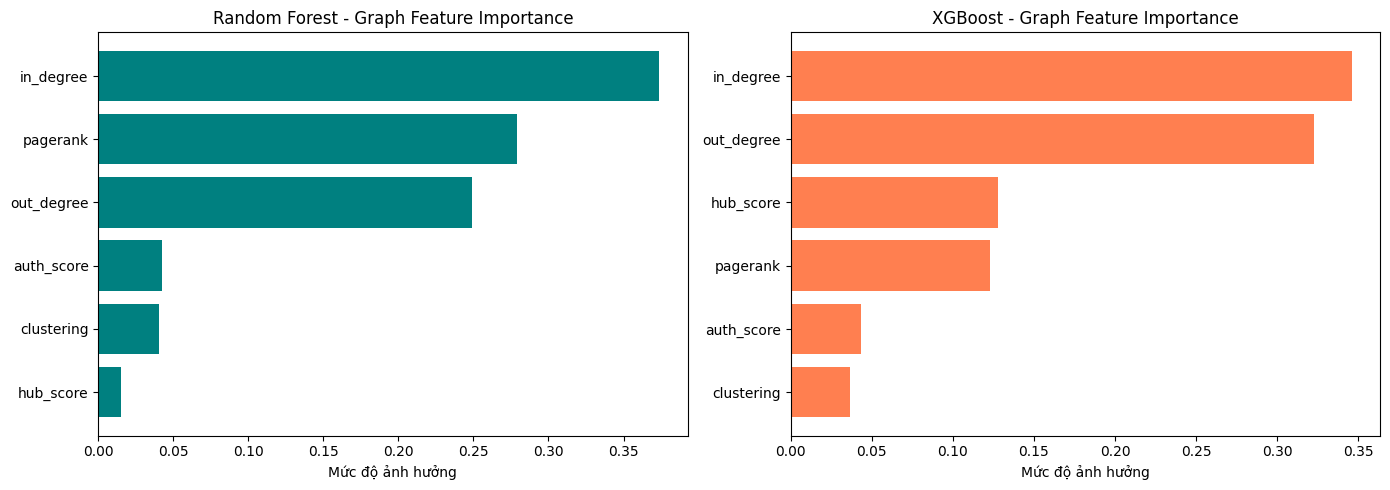

In [7]:
# Trích xuất Importance từ thuật toán XGBoost và Random Forest mà ta đã fit ở trên
rf_model = models["Random Forest"]
xgb_model = models["XGBoost"]

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ Random Forest
rf_importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=True)
ax[0].barh(rf_importances.index, rf_importances.values, color='teal')
ax[0].set_title('Random Forest - Graph Feature Importance')
ax[0].set_xlabel('Mức độ ảnh hưởng')

# Biểu đồ XGBoost
xgb_importances = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values(ascending=True)
ax[1].barh(xgb_importances.index, xgb_importances.values, color='coral')
ax[1].set_title('XGBoost - Graph Feature Importance')
ax[1].set_xlabel('Mức độ ảnh hưởng')

plt.tight_layout()
plt.show()